<a href="https://colab.research.google.com/github/manuelagutierrezss16/Integraci-n-de-Datos-y-Prospectiva/blob/main/1_INTEGRACION_DE_DATOS_(MUESTREO)_CLASE_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

** Caso Estudio - Primer Método Integración**

EL primer método de integración se conoce como el metodo de muestreo(por clusterización). Este método está determinado por el indice de confiabilidad. De manera general la confiabilidad a norma internacional esta marcado por una confiabilidad del 99.9%, lo que requerira como minimo tener un total de 1000 datos.

0. Cargar librerias

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

1. Cargqamos los datos de trabajo

/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Conditional Formatting extension is not supported and will be removed
  warn(msg)


,Semana,Transacción Semanales,Valor Transado (MUSD),Eventos (Semana),Severidad (KUSD),Riesgo,LDA (EVENTOS* SEVERIDAD),Unnamed: 7,Unnamed: 8,Unnamed: 9,intervalo,Limite inferior,Limite superior,# de datos,Peso riesgo (fi)
0,1,44,27.145501,4,2.867141,Riesgo de Error en Reportes No Críticos,11.468562,Maximo,3065.901730,NaN,1.0,2.599197,308.929450,2209.0,0.787803
1,2,194,68.447342,20,6.420941,Riesgo Regulatorio,128.418827,Minimo,2.599197,NaN,2.0,308.929450,615.259703,356.0,0.126961
2,3,217,20.111928,22,2.174181,Riesgo de Error en Reportes No Críticos,47.831980,Rango,3063.302533,NaN,3.0,615.259703,921.589957,116.0,0.041369
3,4,278,60.008094,28,5.816689,Riesgo Logístico y de Cadena de Suministro,162.867297,Numero intervalos,10.000000,recomendación,4.0,921.589957,1227.920210,46.0,0.016405
4,5,286,63.007004,31,6.375786,Riesgo Regulatorio,197.649353,Tamaño intervalo,306.330253,dolares,5.0,1227.920210,1534.250463,27.0,0.009629
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2799,2800,39,23.886707,4,2.613396,Riesgo de Error en Reportes No Críticos,10.453583,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2800,2801,319,40.392800,29,3.666040,Riesgo Administrativo Menor,106.315153,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2801,2802,495,19.572457,53,1.905119,Riesgo de Equipamiento Secundario,100.971315,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2802,2803,197,14.077296,19,1.329140,Riesgo de Equipamiento Secundario,25.253669,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


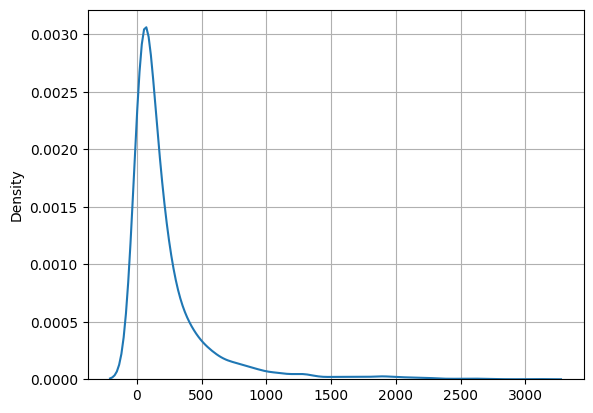

In [ ]:
nxl= '/content/1. RiesgoOperacional_EVERGREEEN.xlsx'
XDB= pd.read_excel(nxl,sheet_name=0)
display (XDB)
Freq= XDB.iloc[:,3];Sev=XDB.iloc[:,4]
LDA= Freq*Sev

plt.figure()
sns.kdeplot(LDA)
plt.grid()
plt.show()


2. Se procede con la creación de los concentradores de información.

In [ ]:
import random
random.seed(42)
XC=np.array(random.choices (LDA,k=5))
XC= np.sort(XC) #ORGANIZA DE MENOR A MAYOR
print("Los concentradores de información son:",XC)

Los concentradores de información son: [ 66.68668397  83.48720974  85.08350368 192.09214682 203.24462183]


3. Se clasifican los datos de acuerdo con los concentradores de información

In [ ]:
d= np.abs(XC-LDA.iloc[0,]) #La distancia de un dato a un concentrador
nc= np.argmin(d)
print("El dato pertenece a la categoria:",nc)
# aca nos dice ell dato seleccionado en que categoria esta (a cual se parece más)

El dato pertenece a la categoria: 0


In [ ]:
box0= [];box1=[];box2= [];box3=[];box4= []
Boxes=[box0,box1,box2,box3,box4]
for k in range(len(LDA)):
    d= np.abs(XC-LDA.iloc[k,])/XC
    #Acá se divide para que de numeros mas pequeños (entre 0 y 1)
    nc= np.argmin(d) # Numero de la caja en donde voy a meter el dato
    Boxes[nc].append(LDA.iloc[k,])

  Boxes[0]  #CLICK DERECHO EJECUTAR SELECCION
  Boxes[4] # perdidads catastroficas

In [ ]:
# CUANTOS DATOS HAY EN CADA CAJA
print(len(Boxes[0]),len(Boxes[1]),len(Boxes[2]),len(Boxes[3]),len(Boxes[4]))
# DETERMINAR EL PORCENTAJE DE DATOS POR CAJA


pm=[] #Vector dde porcentajes
for j in range (5):
  pd=len(Boxes[j])/len(LDA)
  pm.append(pd)
print("El porcentaje de los datos es:",pm)
pm= (np.array(pm)*1000).astype(int)
print("EL porcentaje de datos que se usan es:",pm) # cuantos datos saco de cada caja si necesito mil datos

1065 105 261 438 935
El porcentaje de los datos es: [0.3798145506419401, 0.037446504992867335, 0.09308131241084165, 0.15620542082738945, 0.3334522111269615]
EL porcentaje de datos que se usan es: [379  37  93 156 333]


4. Sacamos datos por caja y creamos una LDA 2

(998,)
La media de los datos observados es: 231.2666023410175
La media de los datos externos es: 225.24909640896917
El error relativo porcentual es: 2.601977921211089


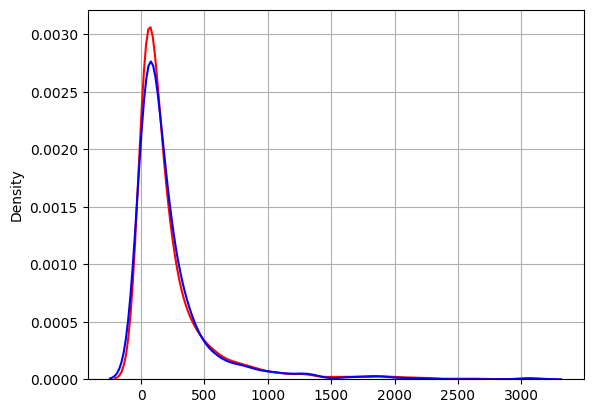

In [ ]:
LDA2=[] #Aqui van a quedar los 1000 datos
# random.choices(Boxes[0],k=379)

for j in range(5):
  LDA2. extend(random.choices(Boxes[j],k=pm[j]))
LDA2=np.array (LDA2)

print(LDA2.shape)

# se comprueban las metricas estadisticas
uo=np.mean(LDA) #datos observados son los originales
print("La media de los datos observados es:",uo)
ue=np.mean(LDA2) #datos externos, los que seleccionamos
print("La media de los datos externos es:",ue)

du=(uo-ue)/uo
print("El error relativo porcentual es:",du*100)

plt.figure()
sns.kdeplot(LDA, color='red', label='Datos Observados')
sns.kdeplot(LDA2, color='blue', label='Datos Externos')
plt.grid()
plt.show()

#FALTA LA VARIANZA DESVIACION ESTANDAR CURTOSIS...

#Analisis de resultados

De acuerdo con el motodo de integración de datos por muestreo aleatorio y concentradores de informacipon, la discrepancia que se obtuvo para la media de las distribuciones (DATOS OBSERBADOS:LDA, DATOS EXTERNOS:LDA2) estuvo por debajo del -2% en promedio, lo que indica que el 98% de los datos aproximadamente fueron correctamente seleccionados.
Este proceso de muestreo se hizo con el fin de lograr una confiabilidad del 99,9% en la estimacion de las perdidas por dejar contenedores en tierra.

Es importante mencionar que las medias de los datos observados y los externos fueron ....
las desviaciones ...
los coeficientes de asimetria...
y la curtosis fue ...  (fueron muy similares)

HACERLO EN EL EJERCICIO QUE NO ES DE EVERGREEN